# EDA — Purchase Propensity Project, Behavior Data

The goal of this project is to build a propensity model predicting P(purchase | user, category) using behavioral data from an e-commerce platform. In this notebook, I'll review and clean the dataset, and discuss problem framing that is applied in the next features notebook.

Two files: `2019-Oct.csv` and `2019-Nov.csv` (Data source: [REES46 e-commerce behavior dataset](https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store))

Columns: `event_time`, `event_type`, `product_id`, `category_id`, `category_code`, `brand`, `price`, `user_id`, `user_session`.

### Problem Framing

I'll design the problem using the following time windows:

- Feature window: Oct 1–31
- Target window: Nov 1–5

My reasoning is to have a full month of behavioral data and a short, stable prediction window. November e-commerce is generally distorted by Black Friday and its promotional run-up, we'll see a similar pattern in the temporal overview below. Restricting the target to Nov 1–5 avoids this distortion and gives a cleaner propensity framing.

Contents:
1. Imports and Settings
2. Parse CSVs into Parquet
3. Data Overview
4. Temporal Overview
5. Conversion Funnel
6. Category Structure
7. Key Findings
8. Clean and Save

## 1. Imports and Settings

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(20)

DATA_DIR      = '../data/'
FILES         = [DATA_DIR + '2019-Oct.csv', DATA_DIR + '2019-Nov.csv']
PARQUET       = DATA_DIR + 'events.parquet'
CLEAN_PARQUET = DATA_DIR + 'events_clean.parquet'
CUTOFF        = '2019-11-01'

## 2. Parse CSVs into Parquet

Instead of re-parsing both csv files from scratch with every `.collect()`, I'll parse once, write to Parquet and scan this for everything else. `sink_parquet` streams row batches directly to disk without loading the full dataset into memory.

In [2]:
# run once
(
    pl.scan_csv(
        FILES,
        schema_overrides={
            'event_type': pl.Categorical,
            'product_id': pl.Int32,
            'user_id':    pl.Int32,
            'price':      pl.Float32,
        },
    )
    .with_columns(
        pl.col('event_time')
          .str.replace(r' UTC$', '')
          .str.to_datetime('%Y-%m-%d %H:%M:%S'),
        pl.col('category_code').replace('', None),
        pl.col('brand').replace('', None),
    )
    .sink_parquet(PARQUET)
)

In [3]:
# All subsequent cells use this
lf = pl.scan_parquet(PARQUET)
print(lf.schema)

Schema([('event_time', Datetime(time_unit='us', time_zone=None)), ('event_type', Categorical), ('product_id', Int32), ('category_id', Int64), ('category_code', String), ('brand', String), ('price', Float32), ('user_id', Int32), ('user_session', String)])


/var/folders/v0/5t8pswf91nb01hqt5vjpg_b00000gn/T/ipykernel_22613/2351464236.py:3: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(lf.schema)


## 3. Data Overview

In [4]:
# Row count and time range
lf.select(
    pl.len().alias('total_rows'),
    pl.col('event_time').min().alias('time_min'),
    pl.col('event_time').max().alias('time_max'),
).collect()

total_rows,time_min,time_max
u32,datetime[μs],datetime[μs]
109950743,2019-10-01 00:00:00,2019-11-30 23:59:59


In [5]:
# Unique counts
lf.select(
    pl.col('user_id').n_unique().alias('unique_users'),
    pl.col('product_id').n_unique().alias('unique_products'),
    pl.col('user_session').n_unique().alias('unique_sessions'),
    pl.col('brand').n_unique().alias('unique_brands'),
    pl.col('category_code').n_unique().alias('unique_category_codes'),
).collect()

unique_users,unique_products,unique_sessions,unique_brands,unique_category_codes
u32,u32,u32,u32,u32
5316649,206876,23016651,4304,130


In [6]:
lf.head(5).collect()

event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
datetime[μs],cat,i32,i64,str,str,f32,i32,str
2019-10-01 00:00:00,"""view""",44600062,2103807459595387724,null,"""shiseido""",35.790001,541312140,"""72d76fde-8bb3-4e00-8c23-a032df…"
2019-10-01 00:00:00,"""view""",3900821,2053013552326770905,"""appliances.environment.water_h…","""aqua""",33.200001,554748717,"""9333dfbd-b87a-4708-9857-633655…"
2019-10-01 00:00:01,"""view""",17200506,2053013559792632471,"""furniture.living_room.sofa""",null,543.099976,519107250,"""566511c2-e2e3-422b-b695-cf8e6e…"
2019-10-01 00:00:01,"""view""",1307067,2053013558920217191,"""computers.notebook""","""lenovo""",251.740005,550050854,"""7c90fc70-0e80-4590-96f3-13c02c…"
2019-10-01 00:00:04,"""view""",1004237,2053013555631882655,"""electronics.smartphone""","""apple""",1081.97998,535871217,"""c6bd7419-2748-4c56-95b4-8cec9f…"


In [7]:
# Event type distribution
total_rows = lf.select(pl.len()).collect().item()

event_counts = (
    lf.group_by('event_type')
    .agg(pl.len().alias('count'))
    .with_columns((pl.col('count') / total_rows * 100).round(2).alias('pct'))
    .sort('count', descending=True)
    .collect()
)
event_counts

event_type,count,pct
cat,u32,f64
"""view""",104335509,94.89
"""cart""",3955446,3.6
"""purchase""",1659788,1.51


### Null Values

In [8]:
# Null values
lf.select(pl.all().null_count()).collect()

event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,35413780,15331243,0,0,12


In [9]:
# Are null values in category and brand concentrated in a specific event type?
lf.group_by('event_type').agg(
    (pl.col('category_code').is_null().sum() / pl.len() * 100).round(2).alias('category_code_null_pct'),
    (pl.col('brand').is_null().sum() / pl.len() * 100).round(2).alias('brand_null_pct'),
).sort('event_type').collect()

event_type,category_code_null_pct,brand_null_pct
cat,f64,f64
"""cart""",23.57,7.0
"""purchase""",24.56,7.92
"""view""",32.66,14.3


In order to make a prediction on a (user, category)-pair, the model input needs to have the same level of signal. Therefore we cannot work with rows with null category values. I'll consider category structure separately later on, and consider approaches for backfilling these null values using the rest of the data. If this is unsuccessful, we'll need to remove this large number of rows from our data.

#### Duplicate Rows

In [10]:
# Check for exact duplicate rows
n_total  = lf.select(pl.len()).collect().item()
n_unique = (
    lf.unique(subset=['event_time', 'user_id', 'event_type', 'product_id', 'user_session'])
    .select(pl.len())
    .collect()
    .item()
)
print(f'Total rows:     {n_total:,}')
print(f'Unique rows:    {n_unique:,}')
print(f'Duplicates:     {n_total - n_unique:,} ({(n_total - n_unique)/n_total*100:.3f}%)')

Total rows:     109,950,743
Unique rows:    109,819,993
Duplicates:     130,750 (0.119%)


Rows with the same event_time, user_id, event_type, product_id and session must be duplicate data, I'll remove these in the final clean and save step.

## 4. Temporal Overview

In [11]:
# Daily event counts
daily = (
    lf.with_columns(pl.col('event_time').dt.date().alias('date'))
    .group_by(['date', 'event_type'])
    .agg(pl.len().alias('count'))
    .sort('date')
    .collect()
    .pivot(on='event_type', index='date', values='count', aggregate_function='sum')
    .sort('date')
)
daily.head(5)

date,purchase,cart,view
date,u32,u32,u32
2019-10-01,19307,16658,1208280
2019-10-02,19469,17268,1154591
2019-10-03,19255,19323,1088725
2019-10-04,27041,43829,1346320
2019-10-05,23494,35497,1271348


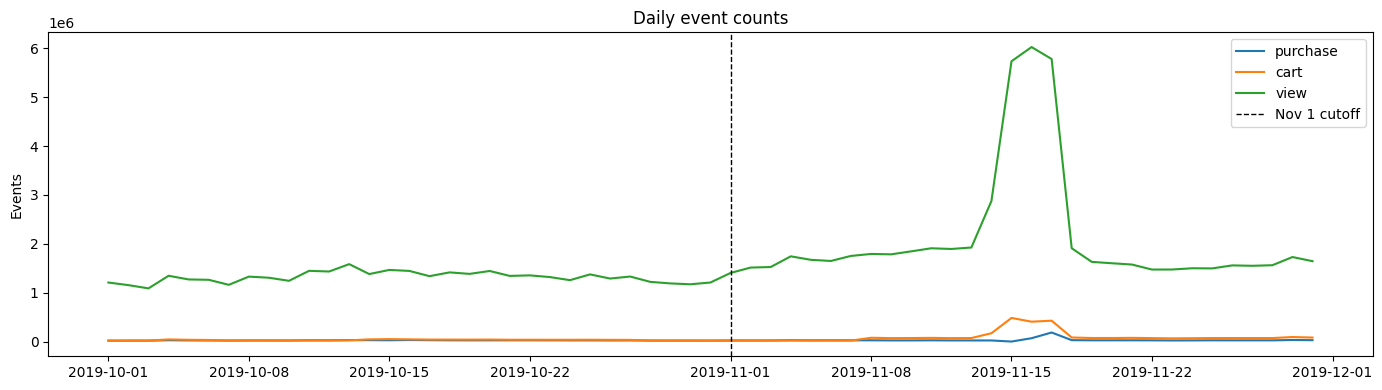

In [12]:
# Time-series plot for the whole data
fig, ax = plt.subplots(figsize=(14, 4))
df_daily = daily.to_pandas().set_index('date')
df_daily.index = pd.to_datetime(df_daily.index)
for col in df_daily.columns:
    ax.plot(df_daily.index, df_daily[col], label=col)
ax.axvline(pd.Timestamp(CUTOFF), color='black', linestyle='--', linewidth=1, label='Nov 1 cutoff')
ax.set_title('Daily event counts')
ax.set_ylabel('Events')
ax.legend()
plt.tight_layout()
plt.show()

The plot validates that the Nov 1–5 choice provides a target window with stable purchase volume. The spike later in November does not correspond to Black Friday exactly, REES46 is a Russian marketplace, so the distortion likely reflects local promotional events.

## 5. Conversion Funnel

In [13]:
# Event-level and user-level funnel in one pass
funnel = (
    lf.group_by('event_type')
    .agg(
        pl.len().alias('events'),
        pl.col('user_id').n_unique().alias('unique_users'),
    )
    .sort('events', descending=True)
    .collect()
)

view_events = funnel.filter(pl.col('event_type') == 'view')['events'].item()
view_users  = funnel.filter(pl.col('event_type') == 'view')['unique_users'].item()

funnel.with_columns(
    (pl.col('events') / view_events * 100).round(2).alias('pct_of_view_events'),
    (pl.col('unique_users') / view_users  * 100).round(2).alias('pct_of_view_users'),
)

event_type,events,unique_users,pct_of_view_events,pct_of_view_users
cat,u32,u32,f64,f64
"""view""",104335509,5316128,100.0,100.0
"""cart""",3955446,1054133,3.79,19.83
"""purchase""",1659788,697470,1.59,13.12


In [14]:
# Sanity check: purchase without view user count should be ~0
purchase_users = lf.filter(pl.col('event_type') == 'purchase').select(pl.col('user_id').unique())
view_users_lf  = lf.filter(pl.col('event_type') == 'view').select(pl.col('user_id').unique())

(
    purchase_users
    .join(view_users_lf, on='user_id', how='anti')
    .select(pl.len().alias('purchase_only_users'))
    .collect()
)

purchase_only_users
u32
286


In [15]:
# Total rows in raw data belonging to the 286 purchase-only users
# Note: actual impact on events_clean is smaller — null-category rows are removed first
no_view_users = purchase_users.join(view_users_lf, on='user_id', how='anti')
lf.join(no_view_users, on='user_id', how='semi').select(pl.len().alias('rows_in_raw')).collect()

rows_in_raw
u32
553


Zero views across two full months is not a plausible scenario, it indicates bad data. I'll exclude all events of these 286 users in the clean and save section below.

## 6. Category Structure

`category_code` is dot-separated: `top.mid.leaf` (e.g. `appliances.environment.water_heater`). I'll use the first level which has 14 unique values as the target category.

Purchases and general activity vary widely across L1 categories. Categories with too few purchases don't provide enough signal to train a reliable propensity model, I'll exclude some categories using a threshold discussed in the features notebook.

In [16]:
# View level 1 and 2 categories
lf_cat = lf.with_columns(
    pl.col('category_code').str.split('.').list.get(0).alias('category_l1'),
    pl.col('category_code').str.split('.').list.get(1).alias('category_l2'),
)

lf_cat.select(
    pl.col('category_l1').n_unique().alias('unique_l1'),
    pl.col('category_l2').n_unique().alias('unique_l2'),
    pl.col('category_code').n_unique().alias('unique_full'),
).collect()

unique_l1,unique_l2,unique_full
u32,u32,u32
14,59,130


In [17]:
# Top L1 categories across all events
lf_cat.group_by('category_l1').agg(pl.len().alias('count')).sort('count', descending=True).head(20).collect()

category_l1,count
str,u32
"""electronics""",40141709
null,35413780
"""appliances""",13457119
"""computers""",6505575
"""apparel""",4554025
"""furniture""",3358989
"""auto""",2227274
"""construction""",1822989
"""kids""",1327003


In [18]:
# Top L1 categories among purchases only
lf_cat.filter(pl.col('event_type') == 'purchase').group_by('category_l1').agg(
    pl.len().alias('purchase_count')
).sort('purchase_count', descending=True).head(20).collect()

category_l1,purchase_count
str,u32
"""electronics""",916667
null,407643
"""appliances""",174022
"""computers""",62332
"""apparel""",22217
"""auto""",21339
"""furniture""",19843
"""construction""",16500
"""kids""",11648


In [19]:
# How many purchase events have no category_code?
lf.filter(pl.col('event_type') == 'purchase').select(
    pl.len().alias('total_purchases'),
    pl.col('category_code').is_null().sum().alias('null_category'),
    (pl.col('category_code').is_null().sum() / pl.len() * 100).round(2).alias('null_pct'),
).collect()

total_purchases,null_category,null_pct
u32,u32,f64
1659788,407643,24.56


Nearly a quarter of the purchases don't have category data, this is a problem since we want to make predictions on (user, category)-pairs. Let's see if we can recover categories using the whole dataset.

#### 6a. Category Recovery Approach 1: Match via `product_id`

In [20]:
# Build product_id → category_code lookup from all non-null rows
product_cat = (
    lf.filter(pl.col('category_code').is_not_null())
    .select(['product_id', 'category_code'])
    .unique(subset=['product_id'], keep='first')
    .collect()
)
print(f'Products with known category: {len(product_cat):,}')

# Check recovery rate on null-category purchases
null_purchases = (
    lf.filter(
        (pl.col('event_type') == 'purchase') &
        (pl.col('category_code').is_null())
    )
    .select('product_id')
    .collect()
)

recoverable   = null_purchases.join(product_cat, on='product_id', how='inner')
unrecoverable = null_purchases.join(product_cat, on='product_id', how='anti')

total_null = len(null_purchases)
print(f'\nNull-category purchases:  {total_null:,}')
print(f'Recoverable via backfill: {len(recoverable):,} ({len(recoverable)/total_null*100:.1f}%)')
print(f'Unrecoverable (drop):     {len(unrecoverable):,} ({len(unrecoverable)/total_null*100:.1f}%)')

Products with known category: 88,691

Null-category purchases:  407,643
Recoverable via backfill: 0 (0.0%)
Unrecoverable (drop):     407,643 (100.0%)


#### 6b. Category Recovery Approach 2: Match via `category_id`

In [21]:
# Build category_id → category_code lookup from non-null rows
cat_id_map = (
    lf.filter(pl.col('category_code').is_not_null())
    .select(['category_id', 'category_code'])
    .unique(subset=['category_id'], keep='first')
    .collect()
)
print(f'Unique category_ids with known code: {len(cat_id_map):,}')

null_purch_cat_ids = (
    lf.filter(
        (pl.col('event_type') == 'purchase') &
        (pl.col('category_code').is_null())
    )
    .select('category_id')
    .collect()
)

recovered = null_purch_cat_ids.join(cat_id_map, on='category_id', how='inner')
n = len(recovered)
total = len(null_purch_cat_ids)
print(f'Recoverable via category_id: {n:,}')

Unique category_ids with known code: 277
Recoverable via category_id: 0


Not being able to recover any category values, I'll remove rows with null category from our data.

## 7. Key Findings

Raw data (Oct 1–Nov 30 2019, before cleaning):

| | |
|---|---|
| Rows | 109.9M |
| Event types | view (94.9%), cart (3.6%), purchase (1.5%) |
| Unique users | 5.3M |
| Unique products | 207k |
| Brands | 4.3k (13.9% of rows null) |
| Category codes | 130 full codes, 14 L1 category values (including nulls, dropped below) |

## 8. Clean and Save

Using our analysis above, I will apply the following cleaning steps:

- Drop rows with null `category_code` (~33% of views, ~24% of cart, ~25% of purchases)
- Drop 12 rows with null `user_session`
- Remove 130,750 duplicate rows with same event_time, user_id, event_type, product_id, user_session (0.119%)
- Exclude all events for users with no view history
- Add `category_l1` once here so downstream notebooks don't recompute it
- Save as `events_clean.parquet`

`events_clean.parquet` retains the full Oct 1–Nov 30 date range. I'll apply window restriction to Oct (features) and Nov 1–5 (labels) in the features notebook.

In [22]:
view_user_ids = (
    pl.scan_parquet(PARQUET)
    .filter(pl.col('event_type') == 'view')
    .select('user_id')
    .unique()
)

(
    pl.scan_parquet(PARQUET)
    .filter(
        pl.col('category_code').is_not_null() &
        pl.col('user_session').is_not_null()
    )
    .join(view_user_ids, on='user_id', how='semi')
    .unique(subset=['event_time', 'user_id', 'event_type', 'product_id', 'user_session'])
    .with_columns(
        pl.col('category_code').str.split('.').list.get(0).alias('category_l1')
    )
    .sink_parquet(CLEAN_PARQUET)
)
print('done')

done


In [23]:
lf_clean = pl.scan_parquet(CLEAN_PARQUET)

# Row count and user count after cleaning
lf_clean.select(
    pl.len().alias('rows'),
    pl.col('user_id').n_unique().alias('unique_users'),
    pl.col('category_l1').n_unique().alias('unique_l1_categories'),
).collect()

rows,unique_users,unique_l1_categories
u32,u32,u32
74435542,4300032,13


In [24]:
# Actual rows removed for the 286 no-view users after all other filters applied
# Note that events with null `category_code` were already removed by the first filter
lf_clean.join(no_view_users, on='user_id', how='semi').select(pl.len().alias('rows_in_clean')).collect()

rows_in_clean
u32
0


In [25]:
# Purchase distribution by L1 category — what we'll predict propensity for
cutoff_ts   = pl.lit(CUTOFF).str.to_datetime('%Y-%m-%d')
nov_6_ts    = pl.lit('2019-11-06').str.to_datetime('%Y-%m-%d')

(
    lf_clean
    .filter(
        (pl.col('event_type') == 'purchase') &
        (pl.col('event_time') >= cutoff_ts) &
        (pl.col('event_time') <  nov_6_ts)
    )
    .group_by('category_l1')
    .agg(
        pl.len().alias('purchases'),
        pl.col('user_id').n_unique().alias('unique_buyers'),
    )
    .sort('purchases', descending=True)
    .collect()
)

category_l1,purchases,unique_buyers
str,u32,u32
"""electronics""",64981,40589
"""appliances""",10309,8100
"""computers""",3899,2921
"""furniture""",1553,1192
"""apparel""",1373,1060
"""auto""",1158,958
"""construction""",1014,789
"""kids""",814,625
"""accessories""",262,201
